# Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys
import os
from pathlib import Path
import glob
import h5py

# Jupyter plotting settings
import seaborn as sns
import matplotlib as mpl

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [15, 5]

In [4]:
# Add project root directory to make imports possible
root_dir = "/lustre/work/akira.tokiwa/Projects/LensingSSC"

project_root = Path(root_dir)
sys.path.append(str(project_root))

from lensing_ssc.utils.io import load_results_from_hdf5
from lensing_ssc.core.fibonacci.fibonacci import FibonacciGrid
from lensing_ssc.core.fibonacci.optimizer import PatchOptimizer
from lensing_ssc.core.fibonacci.plotting import plot_coverage_map, plot_fibonacci_grid
from lensing_ssc.core.fibonacci.coverage import CoverageAnalyzer

# Configuration

In [6]:
# Directory to save results
results_dir = project_root / "output" 
savedir = root_dir + "/output/figures"
os.makedirs(results_dir, exist_ok=True)

## Lonlat related

In [7]:
xsize = 2048
padding = 0.1 + np.sqrt(2)
patch_size_deg = 5
resolution_arcmin = (patch_size_deg * 60.0) / xsize

lats = [-90, -45, 0, 45, 90]
lons = [0, 0, 90, 180, 180]

bigbox_sample_map_paths = ['/lustre/work/akira.tokiwa/Projects/LensingSSC/data/fullsky/bigbox/zs{zs}/kappa_zs{zs}_s100.fits'.format(zs=zs) for zs in [0.5, 1.0, 1.5, 2.0, 2.5]]
tiled_sample_map_paths = ['/lustre/work/akira.tokiwa/Projects/LensingSSC/data/fullsky/tiled/zs{zs}/kappa_zs{zs}_s100.fits'.format(zs=zs) for zs in [0.5, 1.0, 1.5, 2.0, 2.5]]

# Plot

In [8]:
def read_sample_patch(path):
    sample_map = hp.read_map(path)
    sample_patchs = []
    # Generate sample patches for different rotations for all the pairs of (lon, lat)
    for lon, lat in zip(lons, lats):
        sample_patchs.append(
            hp.gnomview(sample_map, rot=[lon, lat], xsize=xsize * padding, reso=resolution_arcmin, return_projected_map=True, nest=True, no_plot=True)
        )
    return sample_patchs

In [9]:
# Read sample maps
bigbox_sample_maps = [read_sample_patch(path) for path in bigbox_sample_map_paths]

# Read tiled sample maps    
tiled_sample_maps = [read_sample_patch(path) for path in tiled_sample_map_paths]

lon: 0, lat: -90


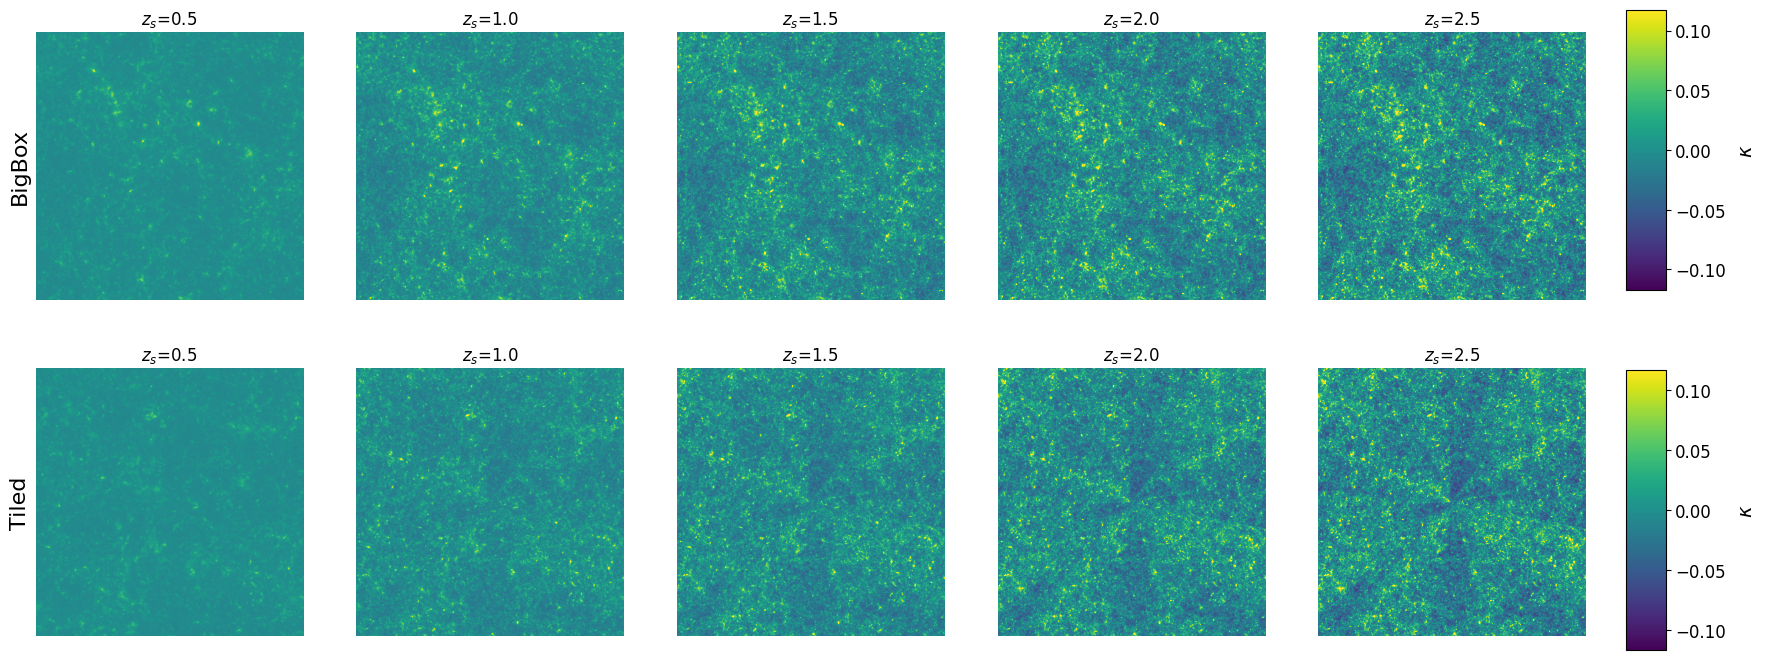

lon: 0, lat: -45


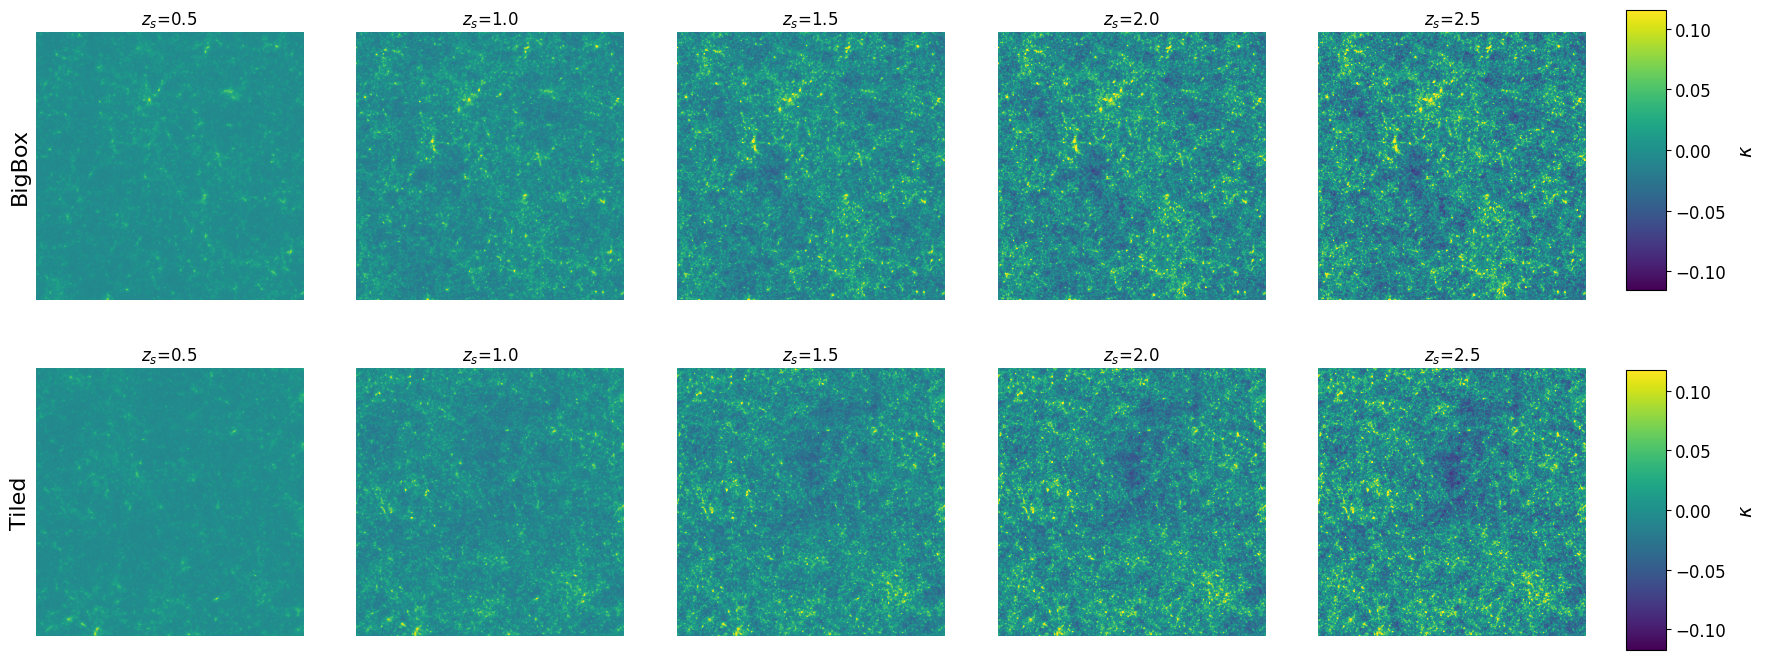

lon: 90, lat: 0


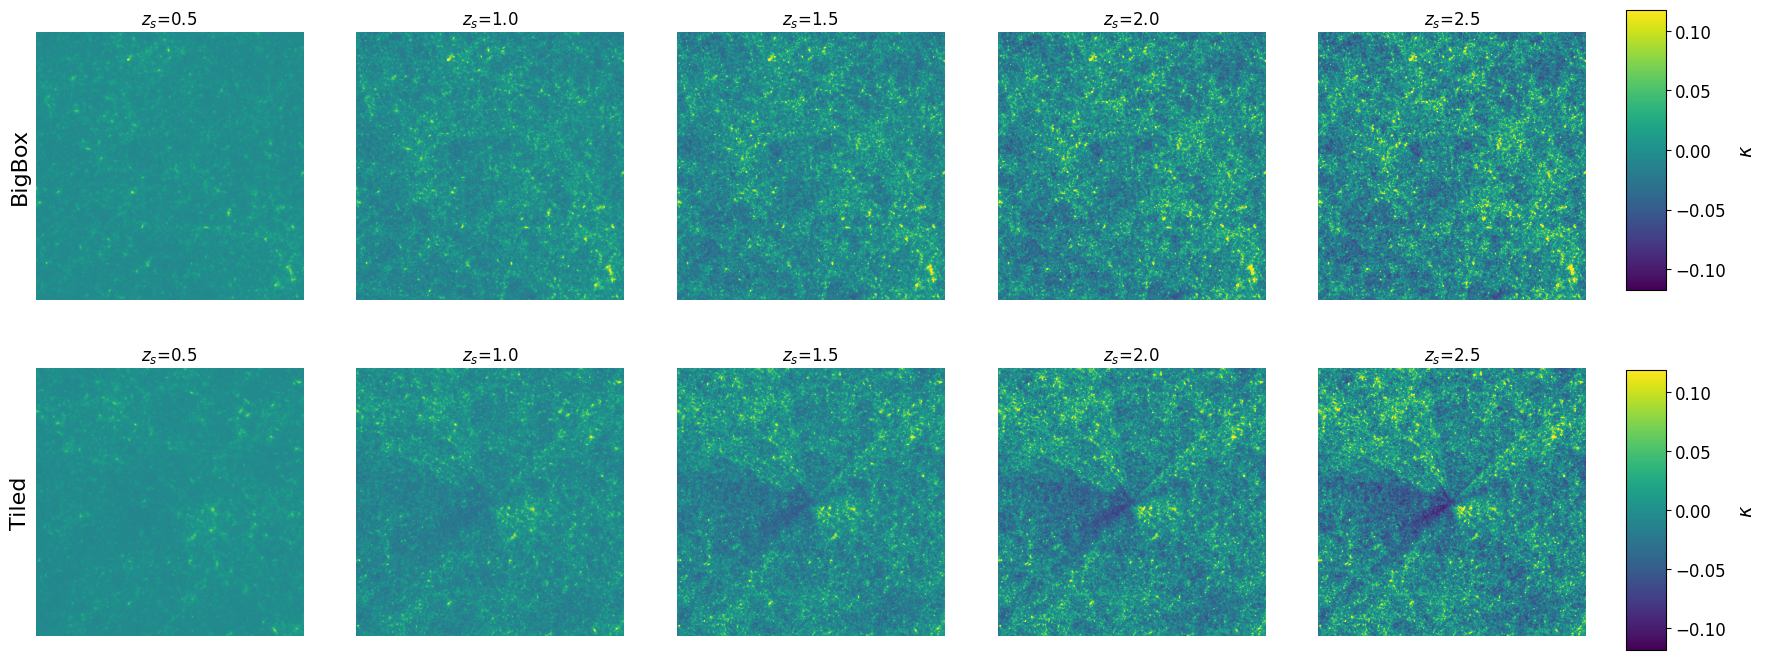

lon: 180, lat: 45


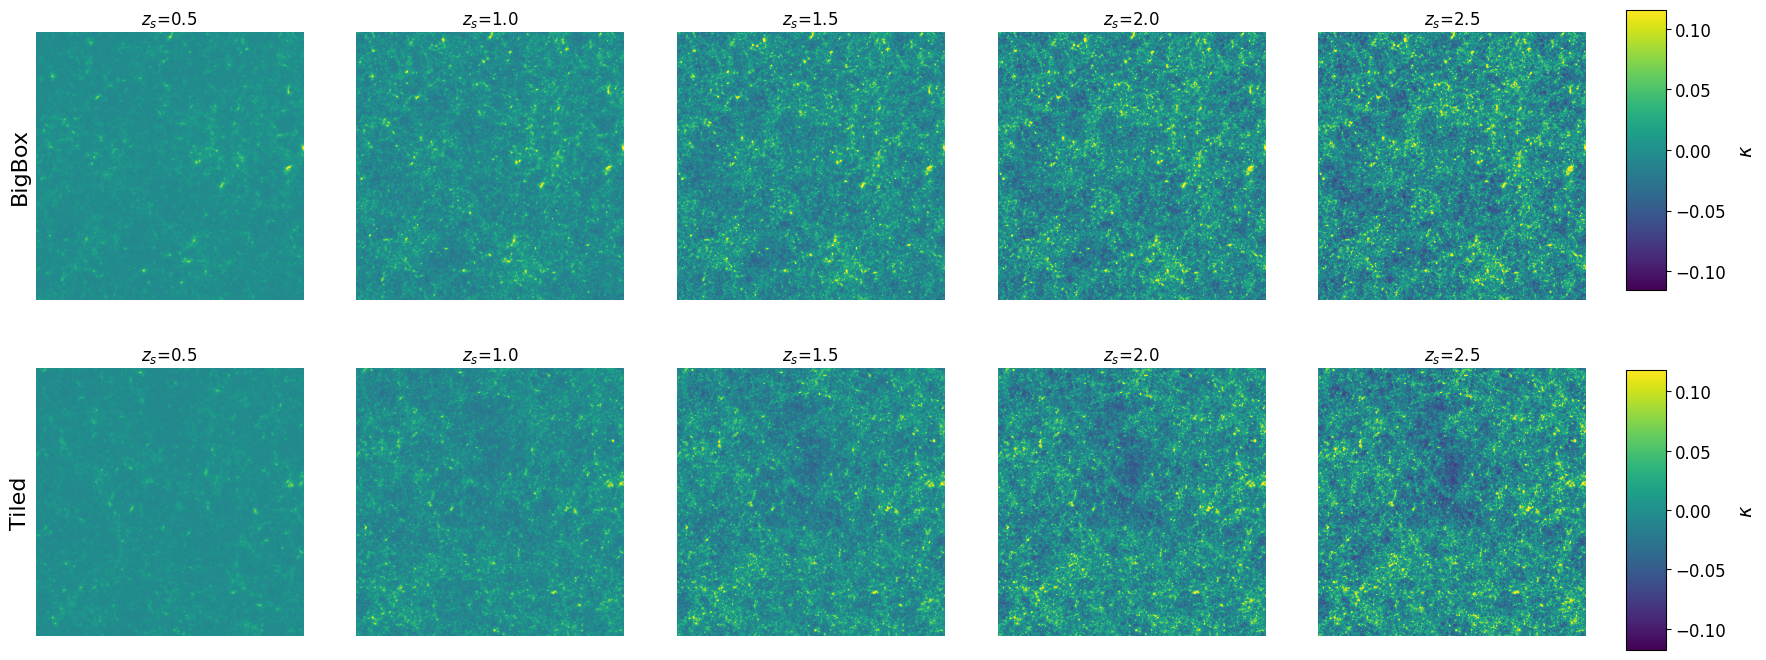

lon: 180, lat: 90


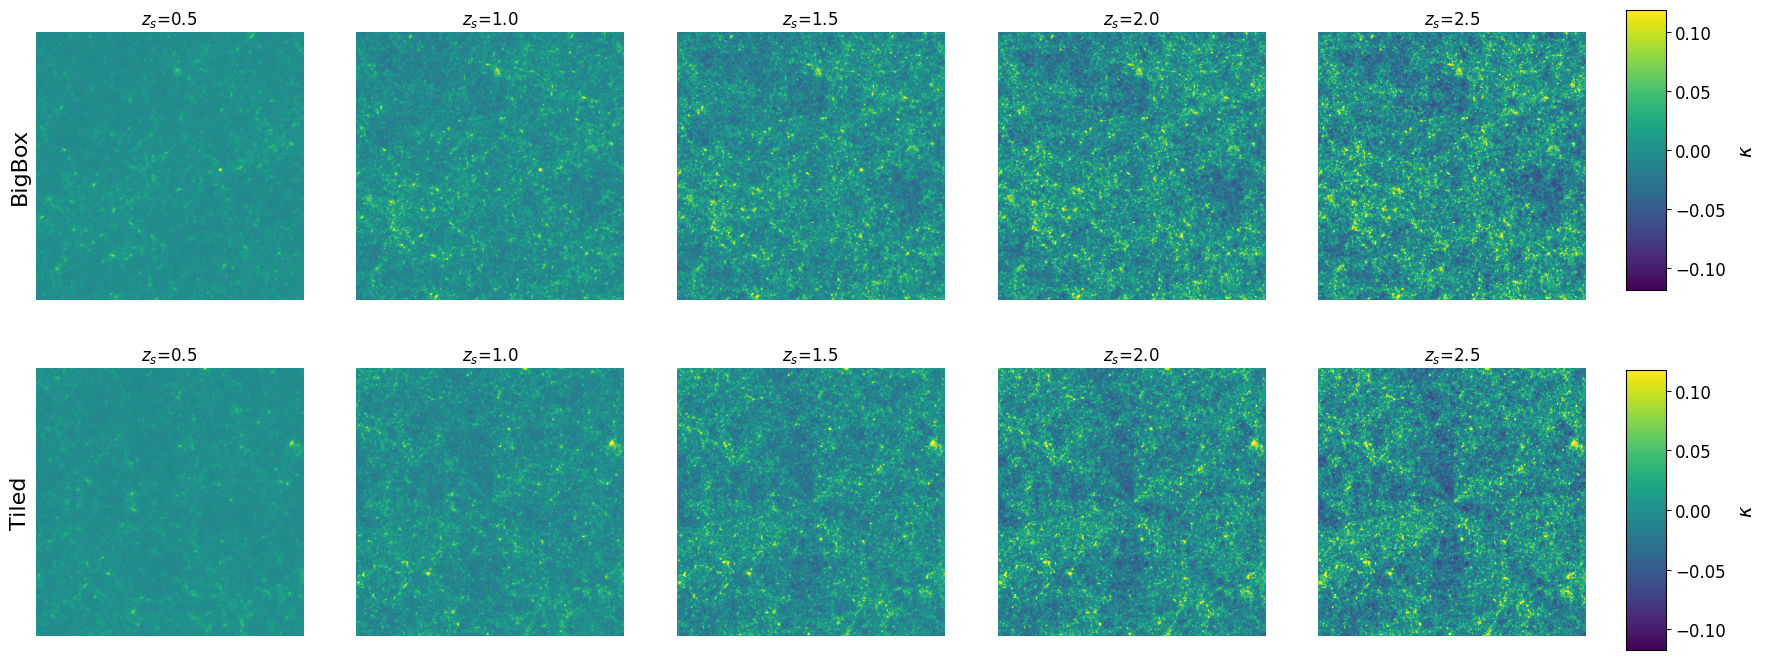

In [10]:
for j, (lon, lat) in enumerate(zip(lons, lats)):
    print(f"lon: {lon}, lat: {lat}")
        
    fig, ax = plt.subplots(2, 5, figsize=(20, 8))

    stderr_bigbox = np.nanstd(bigbox_sample_maps[-1][j])
    vmin_bigbox, vmax_bigbox = - 3 * stderr_bigbox, 3 * stderr_bigbox

    stderr_tiled = np.nanstd(tiled_sample_maps[-1][j])
    vmin_tiled, vmax_tiled = - 3 * stderr_tiled, 3 * stderr_tiled

    # Plot big box sample patches
    for i, (bigbox_map, tiled_map) in enumerate(zip(bigbox_sample_maps, tiled_sample_maps)):
        im_bigbox = ax[0, i].imshow(bigbox_map[j], origin='lower', cmap='viridis', extent=[-xsize * padding / 2, xsize * padding / 2, -xsize * padding / 2, xsize * padding / 2], vmin=vmin_bigbox, vmax= vmax_bigbox)
        im_tiled = ax[1, i].imshow(tiled_map[j], origin='lower', cmap='viridis', extent=[-xsize * padding / 2, xsize * padding / 2, -xsize * padding / 2, xsize * padding / 2], vmin=vmin_tiled, vmax= vmax_tiled)

        ax[0, i].set_title(f'$z_s$={0.5 + i * 0.5}', fontsize=12)
        ax[1, i].set_title(f'$z_s$={0.5 + i * 0.5}', fontsize=12)

        ax[0, i].set_xticks([])
        ax[0, i].set_yticks([])
        ax[0, i].spines['top'].set_visible(False)
        ax[0, i].spines['right'].set_visible(False)
        ax[0, i].spines['bottom'].set_visible(False)
        ax[0, i].spines['left'].set_visible(False)

        ax[1, i].set_xticks([])
        ax[1, i].set_yticks([])
        ax[1, i].spines['top'].set_visible(False)
        ax[1, i].spines['right'].set_visible(False)
        ax[1, i].spines['bottom'].set_visible(False)
        ax[1, i].spines['left'].set_visible(False)

    # add a vertical colorbar on the right
    fig.subplots_adjust(right=0.90)                    # make room on the right
    cax_tiled = fig.add_axes([0.92, 0.1, 0.02, 0.35])        # [left, bottom, width, height]
    cb = fig.colorbar(im_tiled, cax=cax_tiled, orientation='vertical')
    cb.ax.tick_params(labelsize=12)
    cb.set_label(r'$\kappa$', fontsize=14, labelpad=8)

    cax_bigbox = fig.add_axes([0.92, 0.55, 0.02, 0.35])        # [left, bottom, width, height]
    cb_bigbox = fig.colorbar(im_bigbox, cax=cax_bigbox, orientation='vertical')
    cb_bigbox.ax.tick_params(labelsize=12)
    cb_bigbox.set_label(r'$\kappa$', fontsize=14, labelpad=8)

    # Set labels for the big box and tiled maps
    ax[0, 0].set_ylabel('BigBox', fontsize=16)
    ax[1, 0].set_ylabel('Tiled', fontsize=16)

    plt.savefig(f'{savedir}/sample_patches_lon{lon}_lat{lat}.pdf', bbox_inches='tight')
    plt.show()